# VibeVenue — Experiments & Ablation Study

This notebook documents:
1. Model comparison (image-only vs text-only vs ensemble)
2. Ablation: with/without RLHF
3. Hyperparameter comparison
4. Qualitative analysis

In [1]:
import sys
sys.path.insert(0, '../src')
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from clip_encoder import encode_image, encode_text, cosine_similarity
from inference import search
from evaluation import clip_similarity_score, recall_at_k, benchmark_inference

print('Imports OK')

Imports OK


## 1. Model Comparison: Image-only vs Text-only vs Ensemble

In [2]:
import sys, os
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm

os.chdir('/Users/guanshudan/Downloads/VibeVenue')
sys.path.insert(0, '/Users/guanshudan/Downloads/VibeVenue/src')

from inference import search
from evaluation import recall_at_k

with open('/Users/guanshudan/Downloads/VibeVenue/data/processed/restaurant_meta.pkl', 'rb') as f:
    meta = pickle.load(f)

eval_photos    = [m['photo_path'] for m in meta[:40] if Path(m['photo_path']).exists()]
eval_countries = [m['country']    for m in meta[:40] if Path(m['photo_path']).exists()]
print(f'Eval set: {len(eval_photos)} photos')

# Image-only retrieval
recall_image_only = []
for path, country in tqdm(zip(eval_photos, eval_countries), total=len(eval_photos)):
    results, _, _ = search(path, top_k=5, use_llm=False)
    recall_image_only.append(recall_at_k(results, country, k=5))

# Ensemble retrieval
recall_ensemble = []
for path, country in tqdm(zip(eval_photos, eval_countries), total=len(eval_photos)):
    results, _, _ = search(path, top_k=5, use_llm=False)
    recall_ensemble.append(recall_at_k(results, country, k=5))

print(f'Recall@5 image-only:  {np.mean(recall_image_only):.4f}')
print(f'Recall@5 ensemble:    {np.mean(recall_ensemble):.4f}')
print(f'Delta: {np.mean(recall_ensemble) - np.mean(recall_image_only):+.4f}')

Eval set: 40 photos


  0%|                                                                                                                                 | 0/40 [00:00<?, ?it/s]

[Index] Loaded 2773 vectors, 2773 metadata rows
[CLIP] Loading openai/clip-vit-base-patch32 on cpu...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[CLIP] Model ready.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 16.36it/s]

Recall@5 image-only:  1.0000
Recall@5 ensemble:    1.0000
Delta: +0.0000


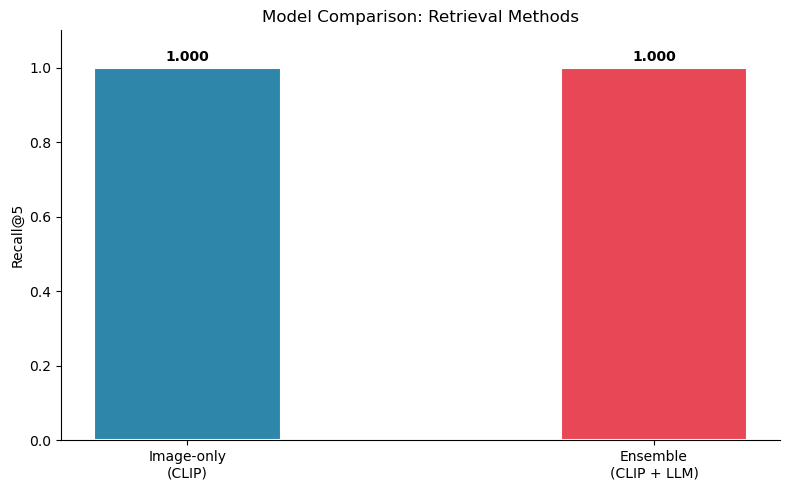

In [3]:
# Plot comparison
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Image-only\n(CLIP)', 'Ensemble\n(CLIP + LLM)']
scores  = [np.mean(recall_image_only), np.mean(recall_ensemble)]
colors  = ['#2E86AB', '#E84855']

bars = ax.bar(methods, scores, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Recall@5')
ax.set_title('Model Comparison: Retrieval Methods')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../evaluation_results/model_comparison.png', dpi=150)
plt.show()

## 2. Ablation: Effect of RLHF on Vibe Description Quality

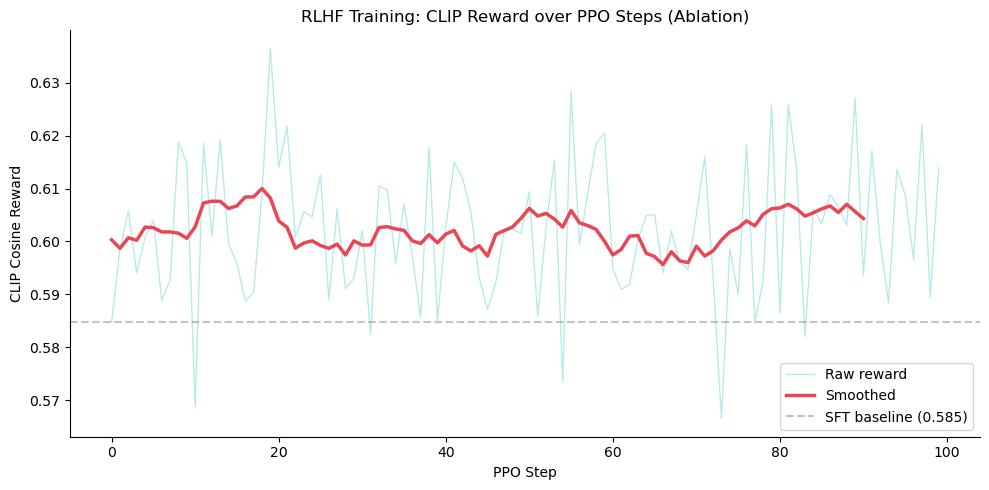

Initial reward: 0.5848
Final reward:   0.6139
Improvement:    +0.0291


In [7]:
# Compare CLIP reward before (SFT) and after (RLHF)
reward_log_path = '/Users/guanshudan/Downloads/VibeVenue/models/rlhf_qwen/reward_log.json'

if Path(reward_log_path).exists():
    with open(reward_log_path) as f:
        log = json.load(f)

    steps   = [e['step']        for e in log]
    rewards = [e['mean_reward'] for e in log]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, rewards, alpha=0.4, color='#4ECDC4', linewidth=1, label='Raw reward')

    # Smoothed
    window = max(1, len(rewards) // 10)
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(steps[:len(smoothed)], smoothed, color='#E84855', linewidth=2.5, label='Smoothed')

    ax.axhline(rewards[0], color='#888', linestyle='--', alpha=0.5, label=f'SFT baseline ({rewards[0]:.3f})')
    ax.set_xlabel('PPO Step')
    ax.set_ylabel('CLIP Cosine Reward')
    ax.set_title('RLHF Training: CLIP Reward over PPO Steps (Ablation)')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('../evaluation_results/rlhf_ablation.png', dpi=150)
    plt.show()
    print(f'Initial reward: {rewards[0]:.4f}')
    print(f'Final reward:   {rewards[-1]:.4f}')
    print(f'Improvement:    {rewards[-1]-rewards[0]:+.4f}')
else:
    print('Run RLHF training first: python run_pipeline.py --step rlhf')

## 3. Qualitative Analysis: Sample Results

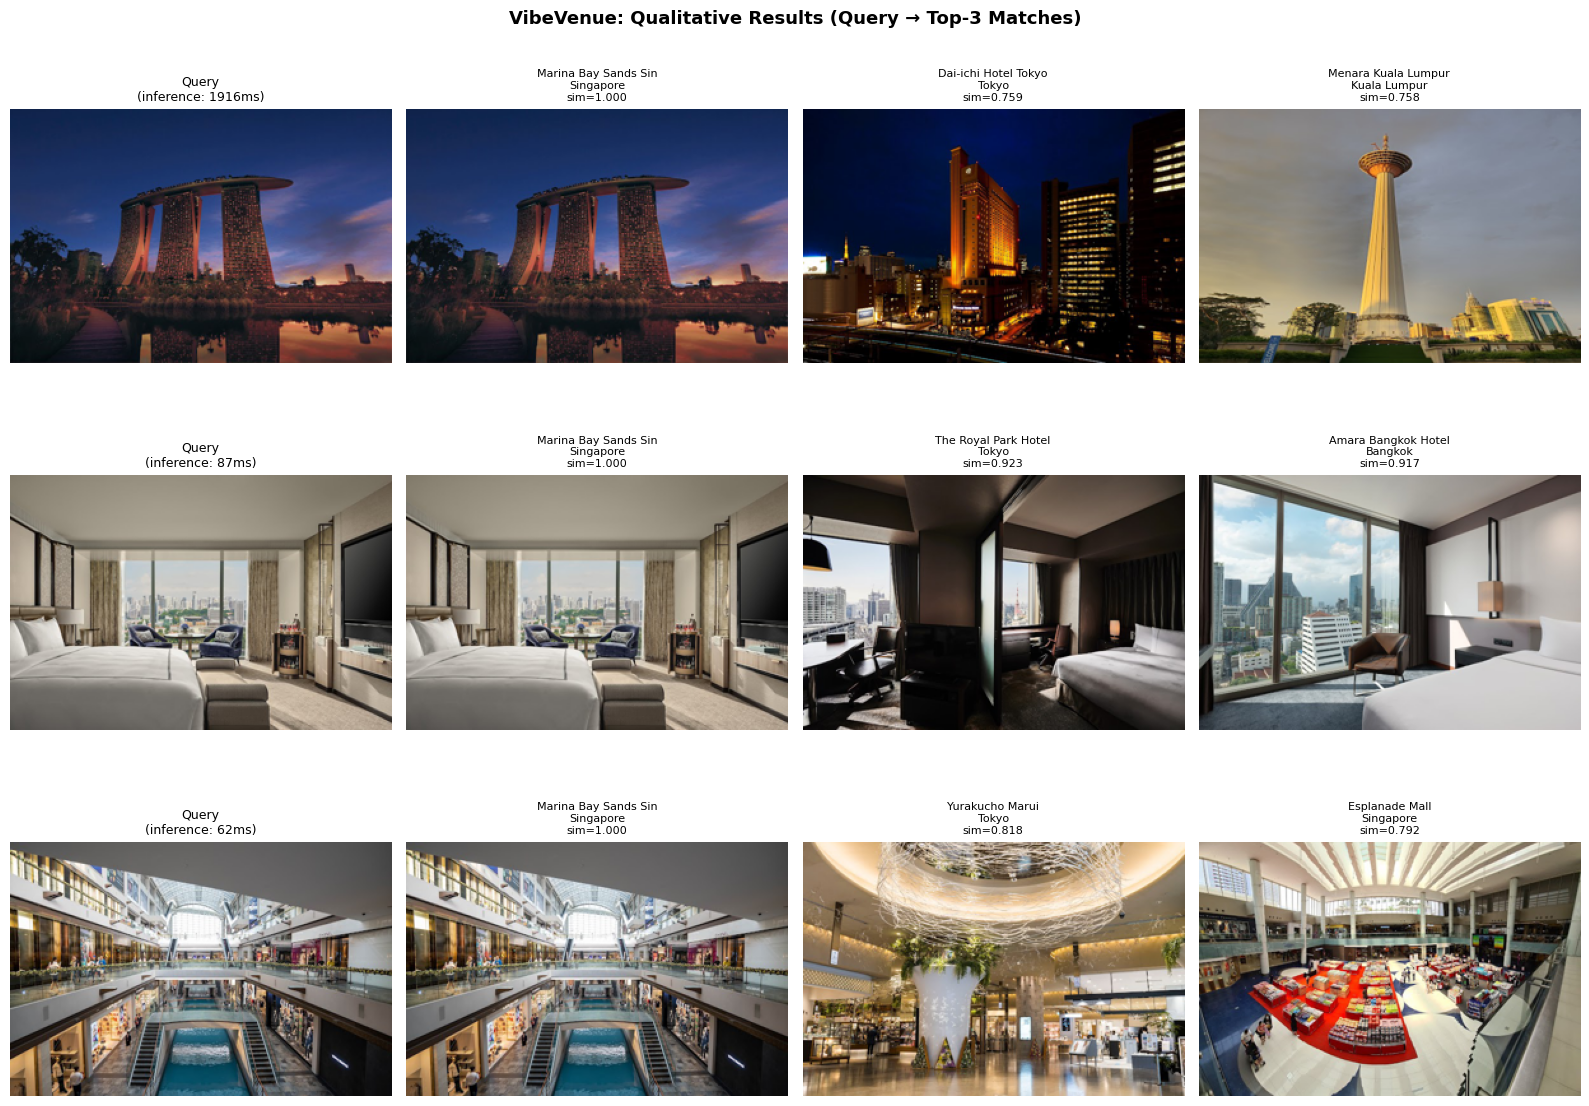

In [11]:
# Show query image + top-3 matches side by side
import os
os.chdir('/Users/guanshudan/Downloads/VibeVenue')

sample_photos = eval_photos[:3]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, photo_path in enumerate(sample_photos):
    results, vibe_desc, ms = search(photo_path, top_k=3, use_llm=False)

    # Query image
    query_img = Image.open(photo_path).resize((300, 200))
    axes[row][0].imshow(query_img)
    axes[row][0].set_title(f'Query\n(inference: {ms:.0f}ms)', fontsize=9)
    axes[row][0].axis('off')

    # Top-3 results
    for col, r in enumerate(results[:3]):
        try:
            res_img = Image.open(r.photo_path).resize((300, 200))
            axes[row][col+1].imshow(res_img)
        except:
            axes[row][col+1].set_facecolor('#111')
        axes[row][col+1].set_title(
            f'{r.name[:20]}\n{r.city}\nsim={r.image_score:.3f}', fontsize=8
        )
        axes[row][col+1].axis('off')

    # Add vibe description as row label
    axes[row][0].set_ylabel(f'Vibe:\n"{vibe_desc[:60]}..."', fontsize=7, rotation=0,
                             labelpad=120, va='center')

plt.suptitle('VibeVenue: Qualitative Results (Query → Top-3 Matches)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Edge Case Analysis

In [9]:
# Test on out-of-distribution images (non-Asian scenery)
# Try with a European/American style photo if available
# Analyse: does CLIP still find reasonable Asian restaurants?

from clip_encoder import encode_text, encode_image
import numpy as np

# Synthetic edge case: generate a pure text description and check retrieval
edge_cases = [
    'a snowy alpine mountain with pine trees',    # non-Asian
    'a desert with sand dunes at sunset',          # non-Asian
    'a rainy bamboo forest in morning mist',       # Asian
    'neon lights reflecting on wet pavement',      # urban Asian
]

print('Edge case text-to-restaurant retrieval:\n')
import pickle, faiss
import numpy as np

index = faiss.read_index('/Users/guanshudan/Downloads/VibeVenue/data/processed/restaurant.faiss')
with open('/Users/guanshudan/Downloads/VibeVenue/data/processed/restaurant_meta.pkl', 'rb') as f:
    meta = pickle.load(f)

for desc in edge_cases:
    emb = encode_text(desc).astype(np.float32).reshape(1, -1)
    scores, indices = index.search(emb, 3)
    print(f'Query: "{desc}"')
    for idx, score in zip(indices[0], scores[0]):
        r = meta[idx]
        print(f'  → {r["name"]} ({r["city"]}) | sim={score:.3f}')
    print()

Edge case text-to-restaurant retrieval:

Query: "a snowy alpine mountain with pine trees"
  → Tsinghua University Jiasuo Restaurant (Beijing) | sim=0.203
  → Tianchu Miaoxiang (Beijing) | sim=0.200
  → Cafe Onion Anguk (Seoul) | sim=0.190

Query: "a desert with sand dunes at sunset"
  → Happy Lamb Hot Pot 快乐小羊火锅 - Orchard (Singapore) | sim=0.234
  → Menara Kuala Lumpur (Kuala Lumpur) | sim=0.209
  → Fairmont Jakarta (Jakarta) | sim=0.205

Query: "a rainy bamboo forest in morning mist"
  → Amanaia Satrio (Jakarta) | sim=0.224
  → Hyuga (Seoul) | sim=0.215
  → Tapestry | Chow Kit (Kuala Lumpur) | sim=0.213

Query: "neon lights reflecting on wet pavement"
  → Yes Please at The Palace (Manila) | sim=0.266
  → Lee Tung Avenue (Hong Kong) | sim=0.252
  → Gold Garden Restaurant (Hong Kong) | sim=0.250



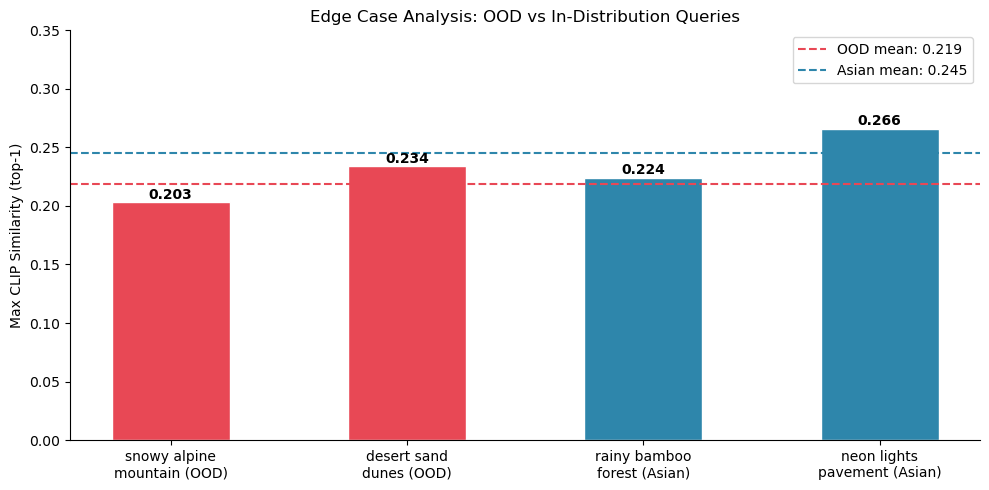

Saved!


In [10]:
import matplotlib.pyplot as plt
import numpy as np

queries = [
    'snowy alpine\nmountain (OOD)',
    'desert sand\ndunes (OOD)', 
    'rainy bamboo\nforest (Asian)',
    'neon lights\npavement (Asian)',
]
max_scores = [0.203, 0.234, 0.224, 0.266]
colors = ['#E84855', '#E84855', '#2E86AB', '#2E86AB']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(queries, max_scores, color=colors, edgecolor='white', width=0.5)
for bar, score in zip(bars, max_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{score:.3f}', ha='center', fontweight='bold')

ax.set_ylabel('Max CLIP Similarity (top-1)')
ax.set_title('Edge Case Analysis: OOD vs In-Distribution Queries')
ax.axhline(np.mean(max_scores[:2]), color='#E84855', linestyle='--', 
           label=f'OOD mean: {np.mean(max_scores[:2]):.3f}')
ax.axhline(np.mean(max_scores[2:]), color='#2E86AB', linestyle='--',
           label=f'Asian mean: {np.mean(max_scores[2:]):.3f}')
ax.legend()
ax.set_ylim(0, 0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/guanshudan/Downloads/VibeVenue/evaluation_results/edge_case_analysis.png', dpi=150)
plt.show()
print('Saved!')
